<a href="https://colab.research.google.com/github/Handinoasa/MachineLearning_2026/blob/main/QUIZ_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quiz 1 Machine Learning

- Nama: Handino Asa Galih R
- Nim: 244107020237
- Kelas: TI 3E

# Load Data Dan Inspect Data

In [ ]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch data
adult_income = fetch_ucirepo(id=2)
X = adult_income.data.features
y = adult_income.data.targets
df = pd.concat([X, y], axis=1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.shape

(48842, 17)

In [ ]:
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [ ]:
# Jawab Soal 1
import numpy as np
df.replace('?', np.nan, inplace=True)

print("--- Info Dataset ---")
df.info()

print("\n--- Jumlah Missing Value ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- Jumlah Missing Value ---
workclass         2799
occupation        2

Deskripsi jawaban: Dalam dataset tersebut, nilai kosong disimbolkan dengan tanda tanya (?), sehingga harus mengubahnya menjadi format standar NaN (Not a Number) agar Pandas bisa menghitung dan memprosesnya.

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [ ]:
# Jawab Soal 2
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Jumlah data hilang setelah imputasi: ", df.isnull().sum().sum())

Jumlah data hilang setelah imputasi:  0


/tmp/ipykernel_947/3528621779.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Deskripsi Jawaban: Karena data yang hilang berjenis teks/kategori (pekerjaan, negara), maka diisi menggunakan Modus (nilai yang paling sering muncul) agar tidak merusak komposisi asli dataset, sehingga tidak dapat memproses algoritma yang kosong.

## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [ ]:
# Jawab Soal 3
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False)
df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Others')
print("Nilai unik pada income:", df['income'].unique())

Nilai unik pada income: ['<=50K' '>50K']


Deskripsi Jawaban: pada umumnya label kategori pada komputer sangat kaku dan biasa dianggap <=50K dan <=50K. sebagai dua hal yang berbeda hanya karena ada tanda titik. Maka, hal yang harus dilakukan adalah membersihkan karakter pengganggu tersebut agar data konsisten.

# Bagian 2 - Visual Inspection

## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

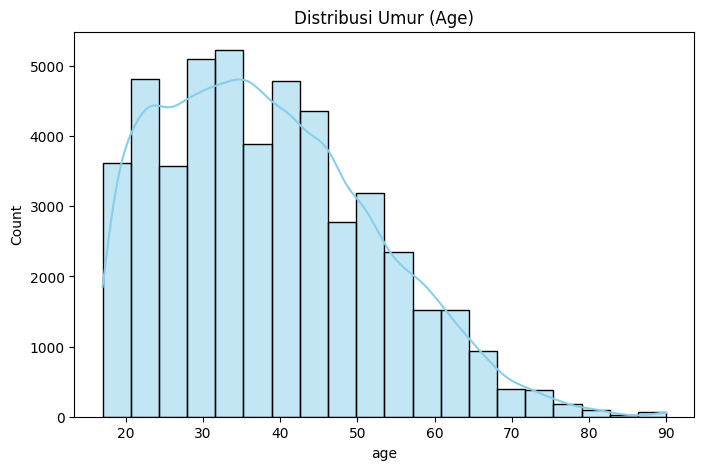

In [ ]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Umur (Age)')
plt.show()

Deskripsi jawaban: Grafik untuk memahami karakteristik data secara sekilas. Histogram untuk melihat sebaran, Barchart untuk menghitung jumlah tiap kategori, Boxplot untuk melihat rentang dan pencilan (outlier), serta Lineplot untuk melihat tren antar dua variabel.

## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

/tmp/ipykernel_947/190764267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='education', data=df, order=df['education'].value_counts().index, palette='viridis')


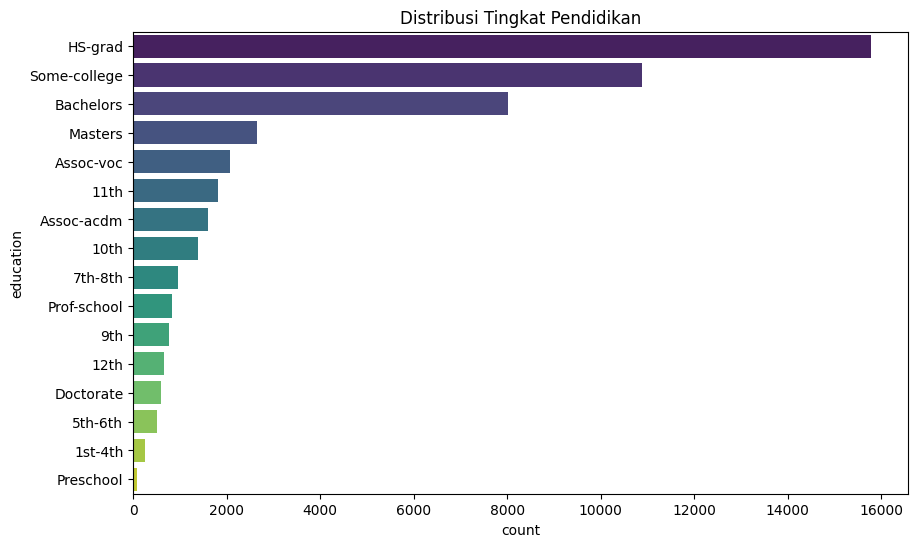

In [ ]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(10, 6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index, palette='viridis')
plt.title('Distribusi Tingkat Pendidikan')
plt.show()

/tmp/ipykernel_947/4232803552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')


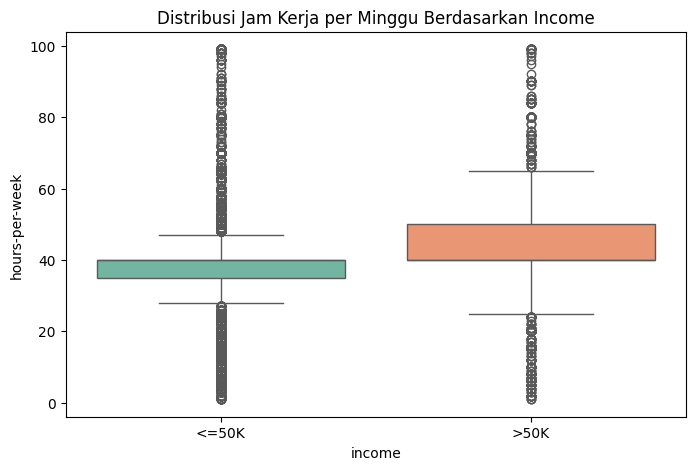

In [ ]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')
plt.title('Distribusi Jam Kerja per Minggu Berdasarkan Income')
plt.show()

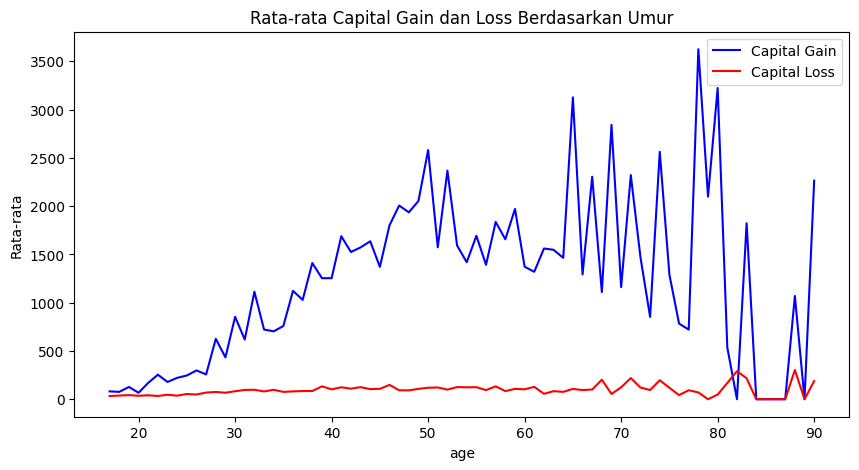

In [ ]:
# Jawab 1.4 - Lineplot
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x='age', y='capital-gain', data=age_capital, label='Capital Gain', color='blue')
sns.lineplot(x='age', y='capital-loss', data=age_capital, label='Capital Loss', color='red')
plt.title('Rata-rata Capital Gain dan Loss Berdasarkan Umur')
plt.ylabel('Rata-rata')
plt.legend()
plt.show()

Deskripsi jawaban: Saat menyadari grafik umur berjenis right-skewed (menumpuk di kiri, memanjang ke kanan), maka menggunakan Mean (rata-rata) untuk mengisi data yang bocor termasuk langkah yang kurang tepat karena akan tertarik oleh nilai ekstrem (orang berumur 90 tahun). sehingga Median (nilai tengah) adalah pilihan yang lebih aman.

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawab dengan komentar python

'''
1. Fenomena pada 'age': Distribusi data bersifat Right-Skewed (condong ke kanan).
   Mayoritas pekerja berada di rentang usia 20-45 tahun, dan jumlahnya menurun
   seiring bertambahnya usia.

2. Strategi data hilang pada 'age': Jika ada, saya akan menggunakan nilai Median.
   Karena distribusi data age condong ke kanan (right-skewed), penggunaan rata-rata
   (mean) tidak ideal karena sangat sensitif terhadap nilai ekstrem (outliers/orang lanjut usia).
   Median lebih merepresentasikan nilai tengah yang tahan terhadap outlier.

3. Dari boxplot, banyak terdapat titik-titik hitam di luar "kumis" (whiskers).
   Kategori income '<=50K' memiliki jumlah outlier paling banyak, baik di rentang
   jam kerja yang sangat rendah maupun jam kerja yang sangat tinggi (ekstrem).
'''

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [ ]:
# Jawab Soal 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
df['income_encoded'] = le.fit_transform(df['income'])
df[['sex', 'sex_encoded', 'income', 'income_encoded']].head()

,sex,sex_encoded,income,income_encoded
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0


Deskripsi Jawban: Prose tersebut menggunakan model Machine Learning berbasis matematika, sehingga tidak bisa melakukan perhitungan dengan teks seperti "Male" atau "Female". Encoding bertugas mengonversi teks tersebut menjadi angka (contoh: 0 dan 1) agar siap dimasukkan ke dalam model.

# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

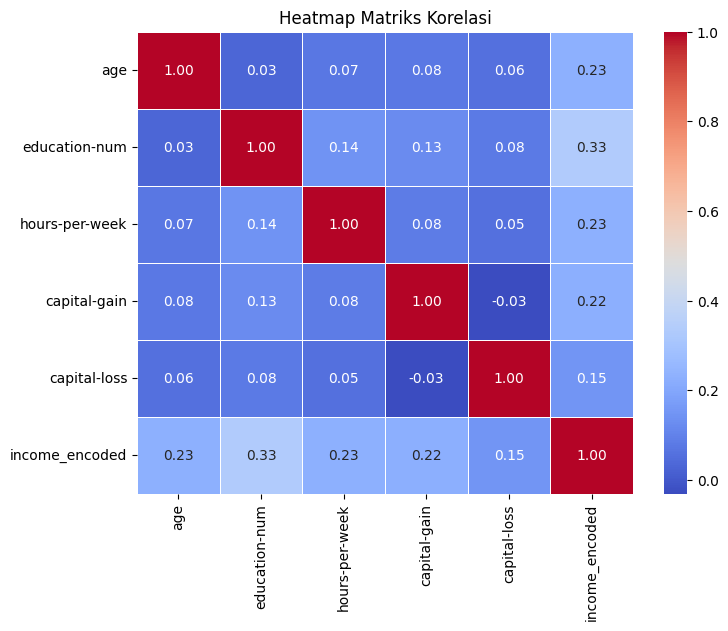

In [ ]:
# Jawaban Soal 1
cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income_encoded']
corr_matrix = df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Matriks Korelasi')
plt.show()

Deskripsi Jawaban: menggunakan Heatmap Korelassi Bertujuan untuk mencari tahu variabel independen apa saja yang paling memengaruhi target (pendapatan) menggunakan rentang angka -1 hingga 1. Semakin tinggi angkanya, semakin kuat pengaruhnya. kemudian dapat dilihat bahwa umur dan durasi edukasi punya dampak positif terbesar terhadap peluang seseorang mendapat gaji tinggi.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Test shape: (10000, 28, 28)


## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

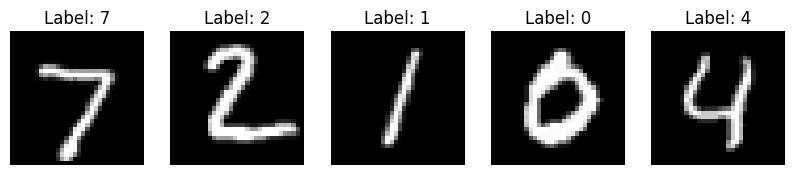

In [ ]:
# Jawab Soal 1: Upsampling
import cv2
X_test_resized = np.zeros((X_test.shape[0], 32, 32), dtype=np.float32)
for i in range(X_test.shape[0]):
    X_test_resized[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

Deskripsi jawaban: Mengubah resolusi gambar dari 28x28 piksel menjadi 32x32 piksel menggunakan OpenCV. Ini adalah persiapan umum karena banyak arsitektur Deep Learning klasik (seperti LeNet) meminta ukuran input gambar pas 32x32 piksel.

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [ ]:
# Jawab Soal 2: Normalisasi
X_test_norm = X_test_resized / 255.0
print("Min pixel:", X_test_norm.min(), "| Max pixel:", X_test_norm.max())

Min pixel: 0.0 | Max pixel: 1.0


Deskripsi jawaban: Secara bawaan, warna piksel gambar berada di rentang 0-255. Membaginya dengan 255 akan memperkecil skalanya menjadi 0-1. Skala kecil dan seragam ini akan membuat perhitungan matematis model (proses iterasi gradient descent) bekerja jauh lebih cepat.

## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [ ]:
# Jawab Soal 3: Flattening
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)
print("Shape setelah flatten:", X_test_flat.shape)

Shape setelah flatten: (10000, 1024)


Algoritma Machine Learning tradisional tidak bisa menerima input berbentuk matriks kotak/2 dimensi. Flattening meratakan gambar 32x32 piksel tersebut menjadi satu baris memanjang berisi 1024 titik angka (array 1D) agar model bisa membacanya sebagai satu kesatuan fitur masukan.